In [1]:
# Task 5: Personal Loan Acceptance Prediction

In [2]:
## Objective
#Predict which customers are likely to accept a personal loan offer.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
## Load Dataset
df = pd.read_csv(r"C:\Task 5\bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
## Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
## Statistical Summary
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
## Check Missing Values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

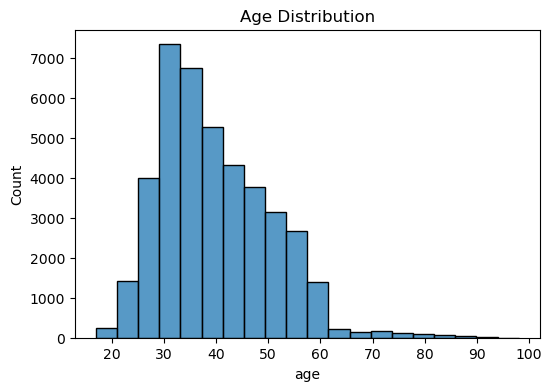

In [9]:
## Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()

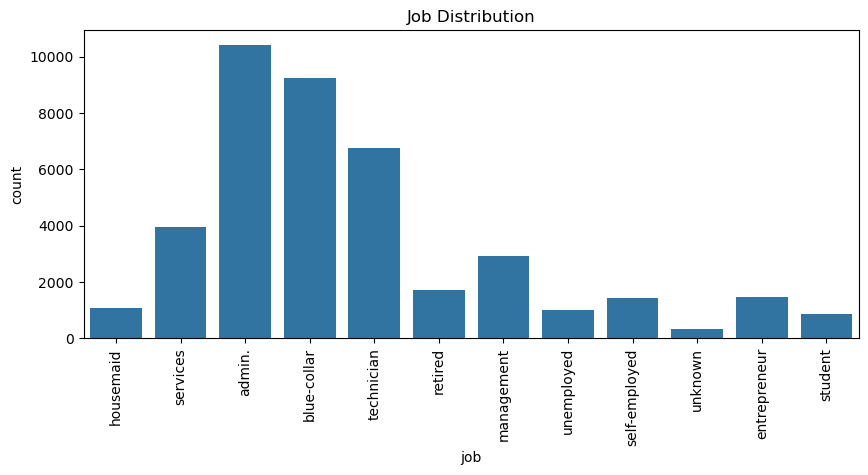

In [10]:
## Job Distribution
plt.figure(figsize=(10,4))
sns.countplot(x='job', data=df)
plt.xticks(rotation=90)
plt.title("Job Distribution")
plt.show()

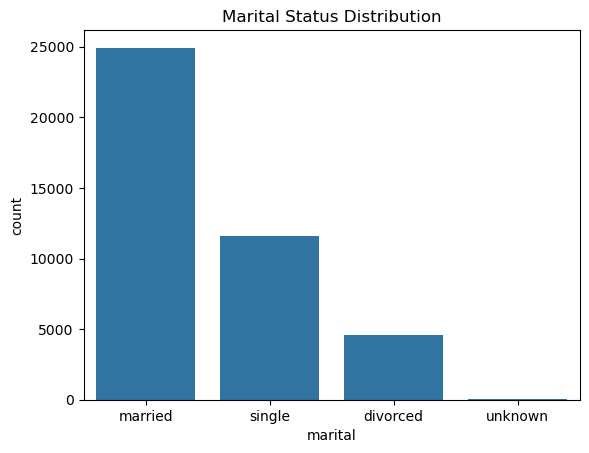

In [11]:
## Marital Status Distribution
sns.countplot(x='marital', data=df)
plt.title("Marital Status Distribution")
plt.show()

In [12]:
## Data Preparation
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [13]:
## Features and Target
X = df.drop('y', axis=1)
y = df['y']

In [24]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
## Train Classification Model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [26]:
## Make Predictions
y_pred = model.predict(X_test)

In [27]:
## Model Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9102937606215101


In [28]:
## Analyze Customer Groups
df.groupby('job')['y'].mean().sort_values(ascending=False)

job
8     0.314286
5     0.252326
10    0.142012
0     0.129726
4     0.112175
11    0.112121
9     0.108260
6     0.104856
3     0.100000
2     0.085165
7     0.081381
1     0.068943
Name: y, dtype: float64

In [29]:
df.groupby('marital')['y'].mean().sort_values(ascending=False)

marital
3    0.150000
2    0.140041
0    0.103209
1    0.101573
Name: y, dtype: float64

In [30]:
age_analysis = df.groupby(
    pd.cut(df['age'], bins=5),
    observed=False
)['y'].mean()

print(age_analysis)

age
(16.919, 33.2]    0.133600
(33.2, 49.4]      0.086116
(49.4, 65.6]      0.118209
(65.6, 81.8]      0.459615
(81.8, 98.0]      0.515152
Name: y, dtype: float64


In [31]:
## Conclusion
print("The dataset was explored using age, job, and marital status.")
print("A Logistic Regression model was trained successfully.")
print("Customer groups with higher loan acceptance rates were identified.")
print("Business insights were extracted from the dataset.")

The dataset was explored using age, job, and marital status.
A Logistic Regression model was trained successfully.
Customer groups with higher loan acceptance rates were identified.
Business insights were extracted from the dataset.
